# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the libraries مهم مكتبة الصور
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps

OUTPUT_DIR = Path(".")


Image mode: L
Image size: (512, 512)


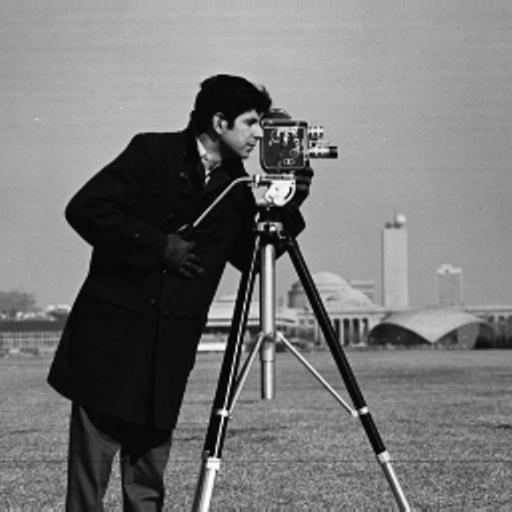

In [ ]:
# ارفع الصوره
image_path = Path("lab_input.jpg")
image = Image.open(image_path).convert("L")

print(f"Image mode: {image.mode}")
print(f"Image size: {image.size}")
display(image)


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [ ]:
# Get the size of the image
width, height = image.size

# Scaling factors
cx, cy = 2, 2
new_width = int(width * cx)
new_height = int(height * cy)

print(f"Original size: {width} × {height}")
print(f"Target size:   {new_width} × {new_height}")


Original size: 512 × 512
Target size:   1024 × 1024


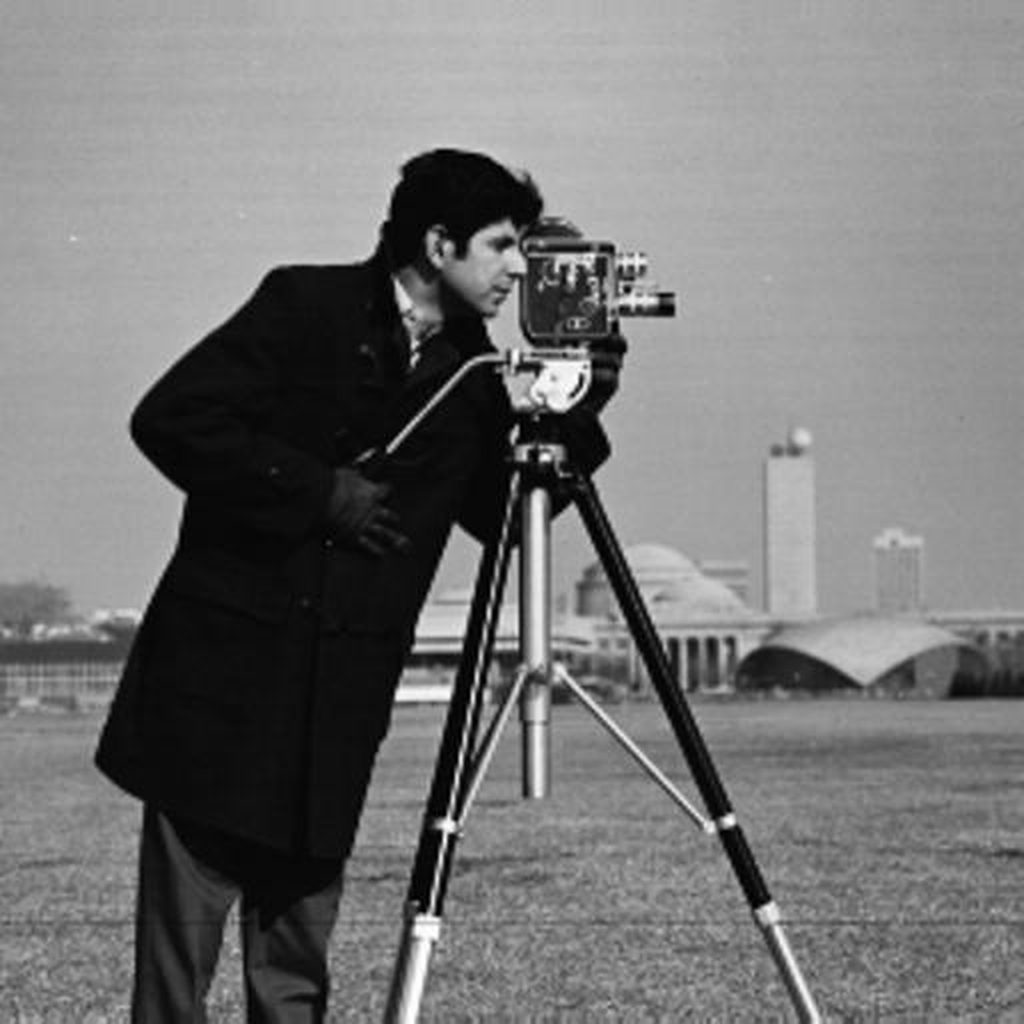

In [ ]:
# ── 1. Increase size (scale ×2) ────────────────────
scaled_image = image.resize(
    (new_width, new_height),
    resample=Image.Resampling.LANCZOS,
)

display(scaled_image)


In [ ]:
# Save the scaled image and print the sizes
scaled_path = OUTPUT_DIR / "task1_1_scaled.jpg"
scaled_image.save(scaled_path, quality=95)

print(f"Original size: {image.size}")
print(f"Scaled size:   {scaled_image.size}")
print(f"Saved as: {scaled_path}")


Original size: (512, 512)
Scaled size:   (1024, 1024)
Saved as: task1_1_scaled.jpg


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [ ]:
# Non-uniform scaling factors: stretch horizontally only
cx_horizontal, cy_vertical = 2, 1

stretched_size = (
    int(width * cx_horizontal),
    int(height * cy_vertical),
)
print(f"Non-uniform target size: {stretched_size}")


Non-uniform target size: (1024, 512)


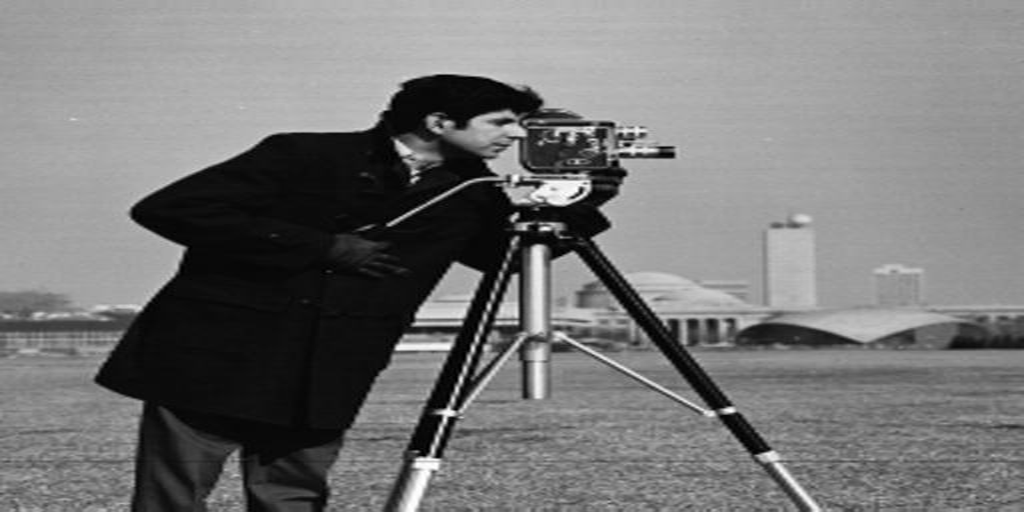

In [ ]:
# Apply the non-uniform scaling
stretched_image = image.resize(
    stretched_size,
    resample=Image.Resampling.LANCZOS,
)
display(stretched_image)


Saved as: task1_1_horizontal_stretch.jpg


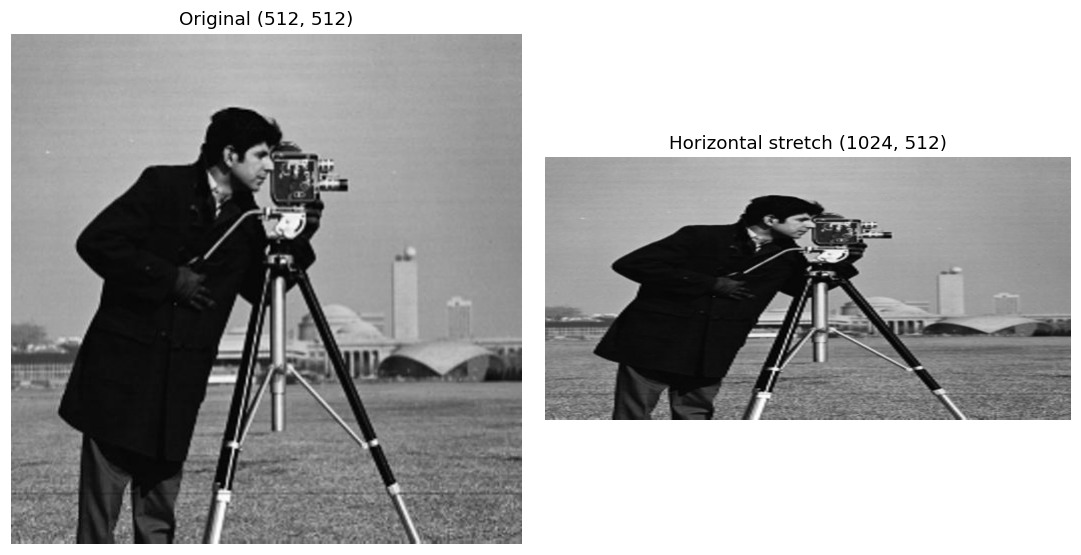

In [ ]:
# Save and compare the non-uniformly scaled result
stretched_path = OUTPUT_DIR / "task1_1_horizontal_stretch.jpg"
stretched_image.save(stretched_path, quality=95)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original {image.size}")
axes[1].imshow(stretched_image, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Horizontal stretch {stretched_image.size}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Saved as: {stretched_path}")


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated canvas size: (700, 700)
Saved as: task1_2_rotated.jpg


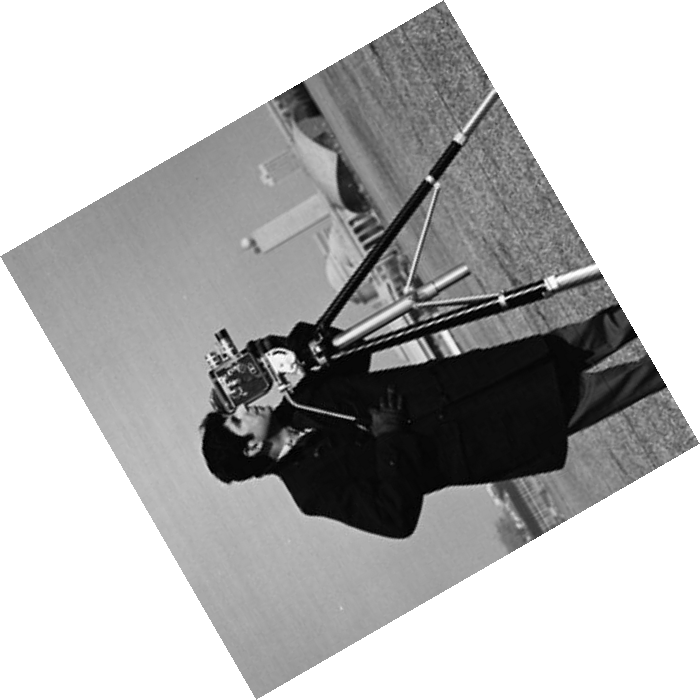

In [ ]:
# ── 2. Rotate 120 degrees ──────────────────────────
# expand=True keeps the complete rotated image instead of cropping it.
rotated_image = image.rotate(
    120,
    resample=Image.Resampling.BICUBIC,
    expand=True,
    fillcolor=255,
)

rotated_path = OUTPUT_DIR / "task1_2_rotated.jpg"
rotated_image.save(rotated_path, quality=95)

print(f"Original size: {image.size}")
print(f"Rotated canvas size: {rotated_image.size}")
print(f"Saved as: {rotated_path}")
display(rotated_image)


### 3. Shear

In [ ]:
# اجيب ابعاد الصوره اول
width, height = image.size
print(f"Width: {width}, Height: {height}")


Width: 512, Height: 512


In [ ]:
# -- d. Define the shear matrix ─────────────────────
# Apply an X-axis shear with a factor of 0.5.
shear_factor = 0.5

# A forward X shear is x' = x + shear_factor*y.
# Its new canvas must be wider by shear_factor*height.
sheared_width = int(round(width + abs(shear_factor) * height))
sheared_height = height

# PIL expects the inverse mapping from output pixels back to input pixels.
inverse_shear = -shear_factor
shear_matrix = (1, inverse_shear, 0, 0, 1, 0)

print(f"Shear factor: {shear_factor}")
print(f"New canvas: {sheared_width} × {sheared_height}")


Shear factor: 0.5
New canvas: 768 × 512


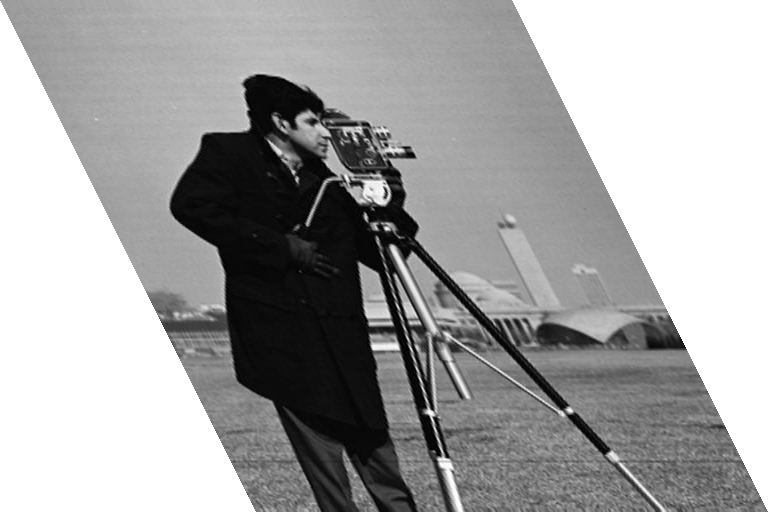

In [ ]:
# -- e. Apply the shear transformation ──────────────
sheared_image = image.transform(
    (sheared_width, sheared_height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=255,
)

display(sheared_image)


In [ ]:
# -- f. Save the sheared image
sheared_path = OUTPUT_DIR / "task1_3_sheared.jpg"
sheared_image.save(sheared_path, quality=95)

print(f"Original size: {image.size}")
print(f"Sheared size:  {sheared_image.size}")
print(f"Saved as: {sheared_path}")


Original size: (512, 512)
Sheared size:  (768, 512)
Saved as: task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

### Experimental comparison

The X-shear results below show that a larger factor produces a stronger horizontal slant and requires a wider canvas. A Y-shear increases canvas height instead. The combined transformation slants the image in both directions.


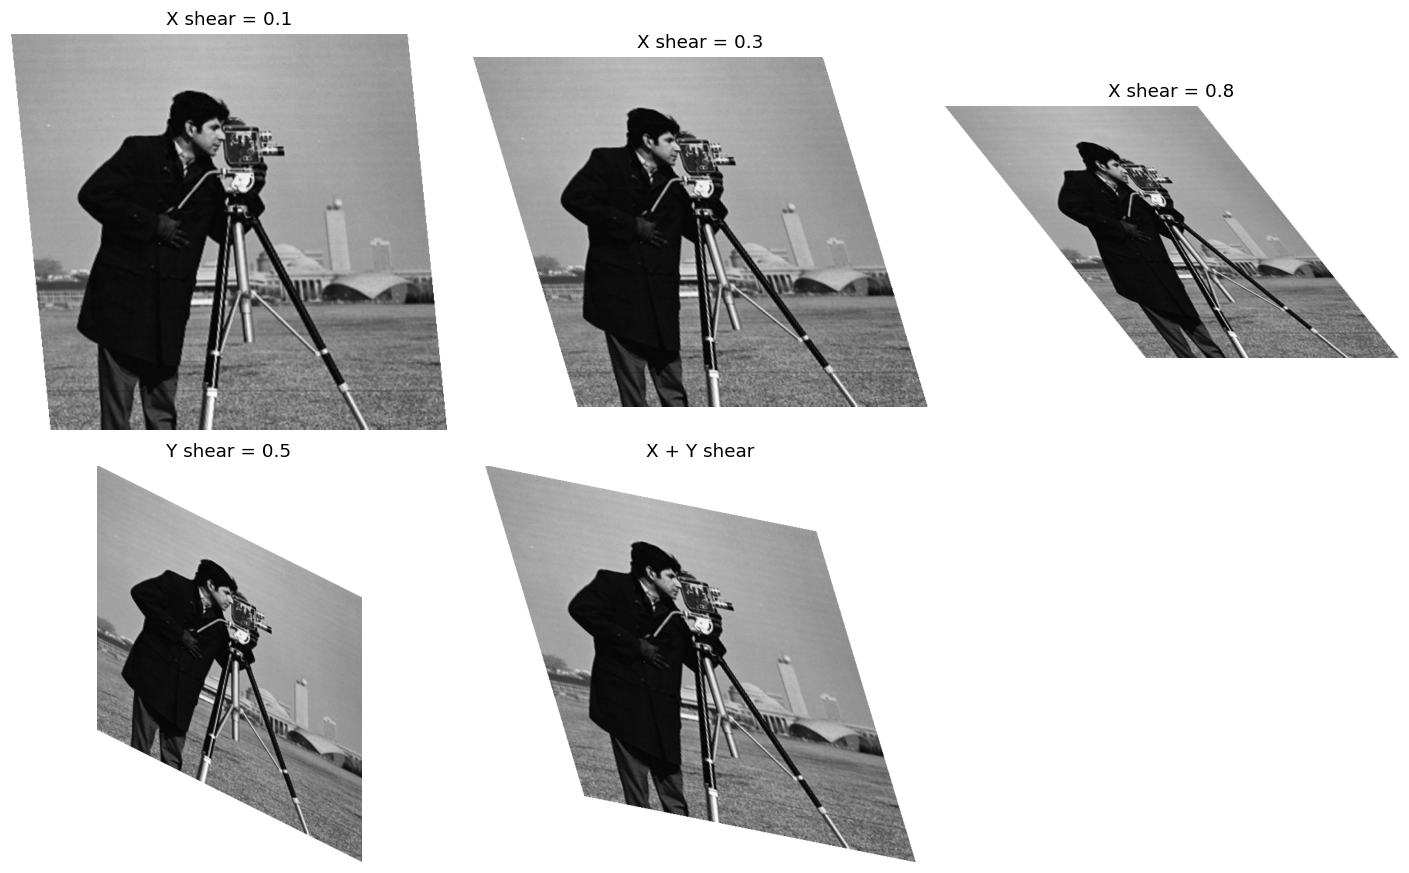

In [ ]:
# Compare X shear factors 0.1, 0.3, and 0.8
def x_shear(source, factor):
    w, h = source.size
    canvas = (int(round(w + abs(factor) * h)), h)
    matrix = (1, -factor, 0, 0, 1, 0)
    return source.transform(
        canvas,
        Image.Transform.AFFINE,
        matrix,
        resample=Image.Resampling.BICUBIC,
        fillcolor=255,
    )


factors = [0.1, 0.3, 0.8]
x_results = [x_shear(image, factor) for factor in factors]

# Y-axis shear: y' = y + factor*x
y_factor = 0.5
y_canvas = (width, int(round(height + abs(y_factor) * width)))
y_matrix = (1, 0, 0, -y_factor, 1, 0)
y_sheared = image.transform(
    y_canvas,
    Image.Transform.AFFINE,
    y_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=255,
)

# Combined X and Y shear in one inverse affine matrix.
x_factor, y_factor = 0.3, 0.2
combined_canvas = (
    int(round(width + abs(x_factor) * height)),
    int(round(height + abs(y_factor) * width)),
)
determinant = 1 - x_factor * y_factor
combined_matrix = (
    1 / determinant,
    -x_factor / determinant,
    0,
    -y_factor / determinant,
    1 / determinant,
    0,
)
combined_shear = image.transform(
    combined_canvas,
    Image.Transform.AFFINE,
    combined_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=255,
)

comparison_images = x_results + [y_sheared, combined_shear]
comparison_titles = [f"X shear = {f}" for f in factors] + ["Y shear = 0.5", "X + Y shear"]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, result, title in zip(axes.flat, comparison_images, comparison_titles):
    ax.imshow(result, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

for factor, result in zip(factors, x_results):
    result.save(OUTPUT_DIR / f"experiment_x_shear_{factor}.jpg", quality=95)
y_sheared.save(OUTPUT_DIR / "experiment_y_shear_0.5.jpg", quality=95)
combined_shear.save(OUTPUT_DIR / "experiment_combined_shear.jpg", quality=95)


# Intensity Transformations
Negative · Log · Power Law (Gamma)

Saved as: task2_1_negative_numpy.jpg


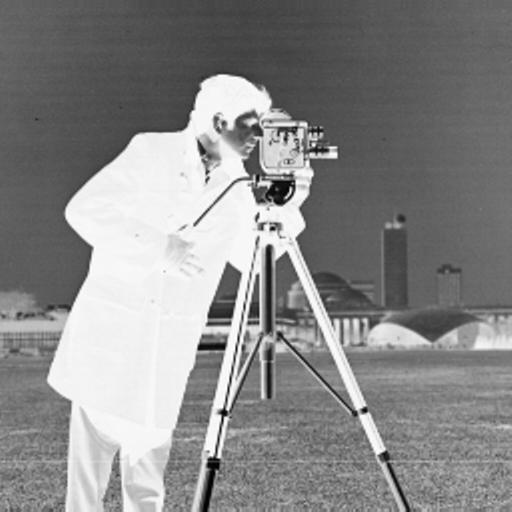

In [ ]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
image_array = np.asarray(image, dtype=np.uint8)
negative_array = 255 - image_array
negative_numpy = Image.fromarray(negative_array)

negative_numpy_path = OUTPUT_DIR / "task2_1_negative_numpy.jpg"
negative_numpy.save(negative_numpy_path, quality=95)

print(f"Saved as: {negative_numpy_path}")
display(negative_numpy)


Both negative methods match: True
Saved as: task2_1_negative_pil.jpg


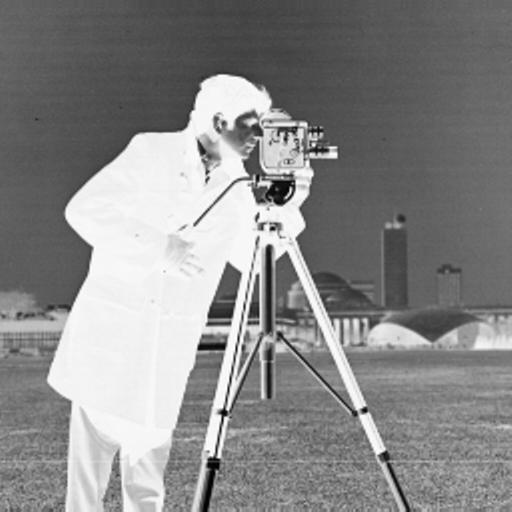

In [ ]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(image)
negative_pil_path = OUTPUT_DIR / "task2_1_negative_pil.jpg"
negative_pil.save(negative_pil_path, quality=95)

# Confirm that both methods give identical pixel values.
methods_match = np.array_equal(np.asarray(negative_numpy), np.asarray(negative_pil))
print(f"Both negative methods match: {methods_match}")
print(f"Saved as: {negative_pil_path}")
display(negative_pil)


Scaling constant c: 45.9859
Saved as: task2_2_log.jpg


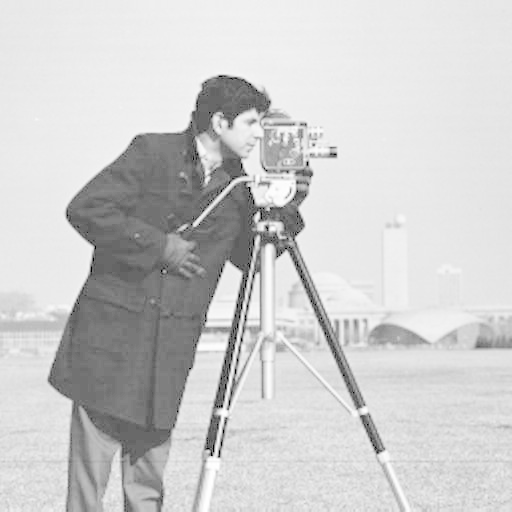

In [ ]:
# ── 2. Log transformation ──────────────────────────
# s = c · log(1 + r), with c chosen so r=255 maps to s=255.
c = 255 / np.log1p(255)

# Convert to float BEFORE adding 1 to prevent uint8 overflow at 255.
float_array = np.asarray(image, dtype=np.float32)
log_array = c * np.log1p(float_array)
log_array = np.clip(log_array, 0, 255).astype(np.uint8)
log_image = Image.fromarray(log_array)

log_path = OUTPUT_DIR / "task2_2_log.jpg"
log_image.save(log_path, quality=95)

print(f"Scaling constant c: {c:.4f}")
print(f"Saved as: {log_path}")
display(log_image)


Gamma: 0.5 (brightens the image)
Saved as: task2_3_gamma.jpg


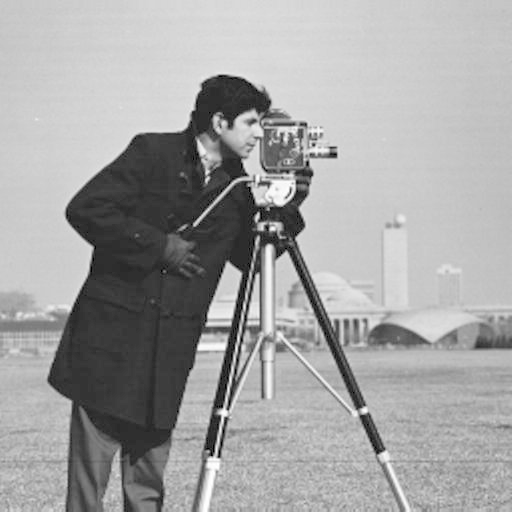

In [ ]:
# ── 3. Power-law / Gamma correction ───────────────
# Normalize to [0, 1], apply s = r^gamma, then return to [0, 255].
gamma = 0.5
normalized = np.asarray(image, dtype=np.float32) / 255.0
gamma_array = 255 * np.power(normalized, gamma)
gamma_array = np.clip(gamma_array, 0, 255).astype(np.uint8)
gamma_image = Image.fromarray(gamma_array)

gamma_path = OUTPUT_DIR / "task2_3_gamma.jpg"
gamma_image.save(gamma_path, quality=95)

print(f"Gamma: {gamma} (brightens the image)")
print(f"Saved as: {gamma_path}")
display(gamma_image)


Observation: the negative reverses intensities; log and gamma < 1 reveal darker details.


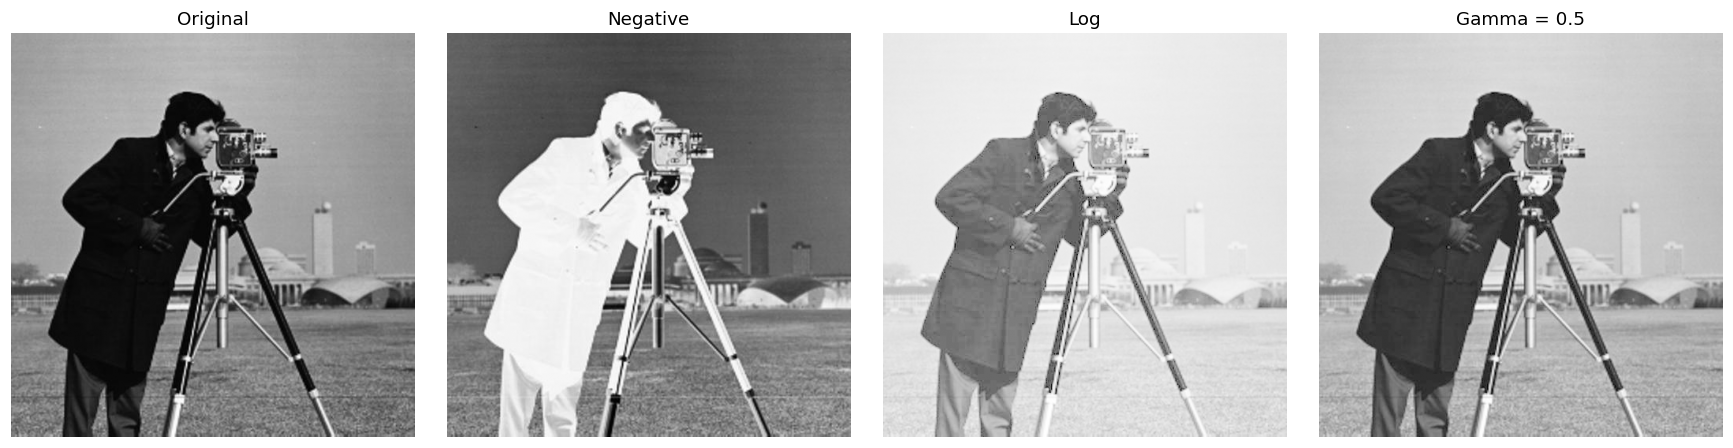

In [ ]:
# Compare the original and all intensity transformations
images = [image, negative_pil, log_image, gamma_image]
titles = ["Original", "Negative", "Log", f"Gamma = {gamma}"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, result, title in zip(axes, images, titles):
    ax.imshow(result, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Observation: the negative reverses intensities; log and gamma < 1 reveal darker details.")
